In [1]:
# ============================================================
# SalesFlow Analytics
# Data Preprocessing
# Korean Startup Style CRM Analytics
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

# =========================
# STYLE SETTINGS
# =========================

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# =========================
# LOAD DATASET
# =========================

print("=" * 60)
print("Loading Dataset")
print("=" * 60)

df = pd.read_excel(
    r"C:\Users\Дима\Desktop\main imir\Python\CRM_new\AdventureWorks Sales Sample.xlsx",
    sheet_name="Sales_data"
)

print("\nDataset Loaded Successfully")

Loading Dataset

Dataset Loaded Successfully


In [2]:
# =========================
# DATASET BEFORE CLEANING
# =========================

print("\n" + "=" * 60)
print("Dataset Before Cleaning")
print("=" * 60)

print(f"\nRows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Dataset Before Cleaning

Rows: 121,253
Columns: 15


In [8]:
# =========================
# MISSING VALUES
# =========================

print("\n" + "=" * 60)
print("Missing Values Analysis")
print("=" * 60)

missing_values = df.isnull().sum()

print("\nMissing Values:\n")
print(missing_values)



Missing Values Analysis

Missing Values:

SalesOrderLineKey          0
ResellerKey                0
CustomerKey                0
ProductKey                 0
OrderDateKey               0
DueDateKey                 0
ShipDateKey                0
SalesTerritoryKey          0
Order Quantity             0
Unit Price                 0
Extended Amount            0
Unit Price Discount Pct    0
Product Standard Cost      0
Total Product Cost         0
Sales Amount               0
dtype: int64


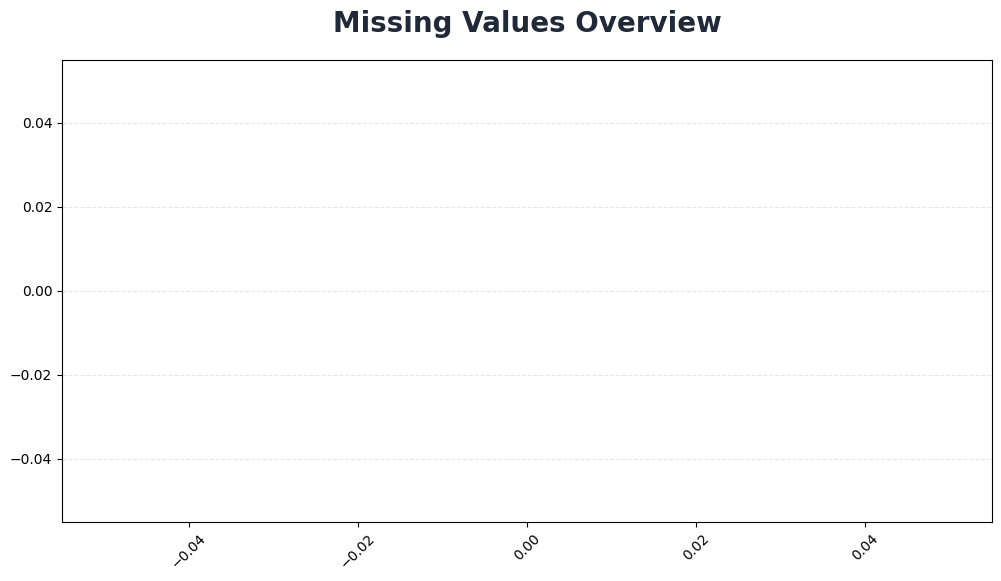

In [9]:
# =========================
# MISSING VALUES CHART
# =========================

missing = missing_values[missing_values > 0]

plt.figure(figsize=(12, 6))

plt.bar(
    missing.index,
    missing.values,
    color="#C4B5FD"
)

plt.title(
    "Missing Values Overview",
    fontsize=20,
    fontweight="bold",
    color="#1F2937",
    pad=20
)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.show()

In [10]:
# =========================
# REMOVE MISSING VALUES
# =========================

before_rows = df.shape[0]

df = df.dropna()

after_dropna_rows = df.shape[0]

print("\n" + "=" * 60)
print("Missing Values Removed")
print("=" * 60)

print(f"\nRows Before: {before_rows:,}")
print(f"Rows After : {after_dropna_rows:,}")


Missing Values Removed

Rows Before: 119,140
Rows After : 119,140


In [11]:
# =========================
# DUPLICATE CHECK
# =========================

print("\n" + "=" * 60)
print("Duplicate Analysis")
print("=" * 60)

duplicates = df.duplicated().sum()

print(f"\nDuplicate Rows: {duplicates:,}")


Duplicate Analysis

Duplicate Rows: 0


In [12]:
# =========================
# REMOVE DUPLICATES
# =========================

before_duplicates = df.shape[0]

df = df.drop_duplicates()

after_duplicates = df.shape[0]

print("\n" + "=" * 60)
print("Duplicates Removed")
print("=" * 60)

print(f"\nRows Before: {before_duplicates:,}")
print(f"Rows After : {after_duplicates:,}")


Duplicates Removed

Rows Before: 119,140
Rows After : 119,140


In [13]:
# =========================
# OUTLIER DETECTION
# =========================

print("\n" + "=" * 60)
print("Outlier Detection")
print("=" * 60)

Q1 = df["Sales Amount"].quantile(0.25)

Q3 = df["Sales Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print(f"\nLower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")


Outlier Detection

Lower Bound: -1618.26
Upper Bound: 2763.74


In [14]:
# =========================
# REMOVE OUTLIERS
# =========================

before_outliers = df.shape[0]

df = df[
    (df["Sales Amount"] >= lower_bound) &
    (df["Sales Amount"] <= upper_bound)
]

after_outliers = df.shape[0]

print("\n" + "=" * 60)
print("Outliers Removed")
print("=" * 60)

print(f"\nRows Before: {before_outliers:,}")
print(f"Rows After : {after_outliers:,}")


Outliers Removed

Rows Before: 119,140
Rows After : 108,552


In [16]:
for col in df.columns:
    print(col)

SalesOrderLineKey
ResellerKey
CustomerKey
ProductKey
OrderDateKey
DueDateKey
ShipDateKey
SalesTerritoryKey
Order Quantity
Unit Price
Extended Amount
Unit Price Discount Pct
Product Standard Cost
Total Product Cost
Sales Amount


In [17]:
# =========================
# LABEL ENCODING
# =========================

print("\n" + "=" * 60)
print("Feature Encoding")
print("=" * 60)

encoder = LabelEncoder()

categorical_columns = [
    "CustomerKey",
    "ProductKey",
    "SalesTerritoryKey"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("\nCategorical Features Encoded Successfully")


Feature Encoding

Categorical Features Encoded Successfully


In [18]:
# =========================
# CLEAN DATASET OVERVIEW
# =========================

print("\n" + "=" * 60)
print("Clean Dataset Overview")
print("=" * 60)

print("\nFirst 5 Rows:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


Clean Dataset Overview

First 5 Rows:

   SalesOrderLineKey  ResellerKey  CustomerKey  ProductKey  OrderDateKey  DueDateKey  ShipDateKey  SalesTerritoryKey  \
0           43659001          676            0         113      20170702    20170712   20170709.0                  4   
2           43659003          676            0         115      20170702    20170712   20170709.0                  4   
3           43659004          676            0         108      20170702    20170712   20170709.0                  4   
4           43659005          676            0         109      20170702    20170712   20170709.0                  4   
6           43659007          676            0         111      20170702    20170712   20170709.0                  4   

   Order Quantity  Unit Price  Extended Amount  Unit Price Discount Pct  Product Standard Cost  Total Product Cost  \
0               1    2024.994         2024.994                        0              1898.0944           1898.0944   
2  

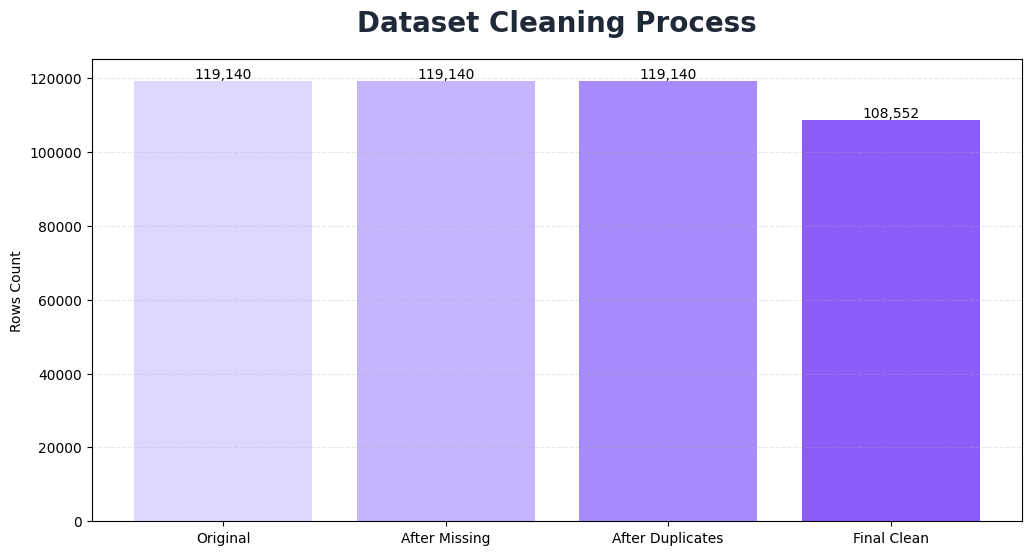

In [19]:
# =========================
# BEFORE VS AFTER
# =========================

stages = [
    "Original",
    "After Missing",
    "After Duplicates",
    "Final Clean"
]

values = [
    before_rows,
    after_dropna_rows,
    after_duplicates,
    after_outliers
]

plt.figure(figsize=(12, 6))

bars = plt.bar(
    stages,
    values,
    color=[
        "#DDD6FE",
        "#C4B5FD",
        "#A78BFA",
        "#8B5CF6"
    ]
)

plt.title(
    "Dataset Cleaning Process",
    fontsize=20,
    fontweight="bold",
    color="#1F2937",
    pad=20
)

plt.ylabel("Rows Count")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.show()

In [20]:
# =========================
# BUSINESS INSIGHTS
# =========================

print("\n" + "=" * 60)
print("Preprocessing Insights")
print("=" * 60)

print("""
1. Missing values were successfully removed.

2. Duplicate records were cleaned.

3. Extreme outliers were filtered using IQR analysis.

4. Categorical features were encoded for machine learning.

5. The dataset is now optimized for:
   - exploratory analysis
   - customer behavior analysis
   - prediction modeling
   - CRM analytics
""")


Preprocessing Insights

1. Missing values were successfully removed.

2. Duplicate records were cleaned.

3. Extreme outliers were filtered using IQR analysis.

4. Categorical features were encoded for machine learning.

5. The dataset is now optimized for:
   - exploratory analysis
   - customer behavior analysis
   - prediction modeling
   - CRM analytics



In [21]:
# =========================
# SAVE CLEAN DATASET
# =========================

df.to_csv(
    "clean_sales_data.csv",
    index=False
)

print("\n" + "=" * 60)
print("Clean Dataset Saved")
print("=" * 60)


Clean Dataset Saved
